### import 

In [76]:
import torch 
import matplotlib.pyplot as plt

In [77]:
from fastai.collab import * 
from fastai.tabular.all import * 

### data (시뮬레이션) 

In [78]:
user = list(range(100))
item = list(range(20))
_lst = [[0,0,4.2]]

In [4]:
def f(u,i): 
    if u<=50 and i<10: 
        return np.random.randn(1)[0]*0.2+4 
    elif u<=50 and i>=10:
        return np.random.randn(1)[0]*0.2+1 
    elif u>50 and i<10:
        return np.random.randn(1)[0]*0.2+1 
    elif u>50 and i>=10:
        return np.random.randn(1)[0]*0.2+4 
        
for u in user:
    _item = np.random.randint(0,20,(10,)).tolist()
    for i in _item:
        _lst.append([u,i,f(u,i)])

In [5]:
_df1=pd.DataFrame(_lst[1:],columns=['user','item','rating'])
_df1

,user,item,rating
0,0,18,1.098652
1,0,17,0.906364
2,0,14,0.789676
3,0,8,3.978475
4,0,18,1.020227
...,...,...,...
995,99,14,4.140413
996,99,14,3.996892
997,99,4,0.932054
998,99,4,1.074552


In [6]:
['커피'+str(i) for i in range(10)]+['홍차'+str(i) for i in range(10)]

['커피0',
 '커피1',
 '커피2',
 '커피3',
 '커피4',
 '커피5',
 '커피6',
 '커피7',
 '커피8',
 '커피9',
 '홍차0',
 '홍차1',
 '홍차2',
 '홍차3',
 '홍차4',
 '홍차5',
 '홍차6',
 '홍차7',
 '홍차8',
 '홍차9']

In [7]:
_df2 = pd.DataFrame({'item':list(range(20)), 'item_name':['커피'+str(i) for i in range(10)]+['홍차'+str(i) for i in range(10)]})
_df2

,item,item_name
0,0,커피0
1,1,커피1
2,2,커피2
3,3,커피3
4,4,커피4
5,5,커피5
6,6,커피6
7,7,커피7
8,8,커피8
9,9,커피9


In [8]:
df= _df1.merge(_df2).sort_values('user') 
df

,user,item,rating,item_name
0,0,18,1.098652,홍차8
320,0,0,3.885489,커피0
366,0,7,3.998325,커피7
161,0,8,3.978475,커피8
162,0,8,3.486676,커피8
...,...,...,...,...
847,99,12,4.175103,홍차2
160,99,14,3.996892,홍차4
159,99,14,4.140413,홍차4
562,99,6,0.378818,커피6


### user-item matrix 

In [9]:
matdf=pd.DataFrame([[None]*20]*100,columns=['커피'+str(i) for i in range(10)]+['홍차'+str(i) for i in range(10)])
matdf

,커피0,커피1,커피2,커피3,커피4,커피5,커피6,커피7,커피8,커피9,홍차0,홍차1,홍차2,홍차3,홍차4,홍차5,홍차6,홍차7,홍차8,홍차9
0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
96,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
97,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
98,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


`-` 아래와 같은 매트릭스를 고려하자. 

In [10]:
for (i,j) in zip(df.user.to_list(), df.item.to_list()):
    matdf.iloc[i,j]=df.query('user == @i and item == @j')['rating'].to_list()[0]

In [11]:
matdf

,커피0,커피1,커피2,커피3,커피4,커피5,커피6,커피7,커피8,커피9,홍차0,홍차1,홍차2,홍차3,홍차4,홍차5,홍차6,홍차7,홍차8,홍차9
0,3.885489,4.139081,3.903375,None,None,None,None,3.998325,3.978475,None,None,None,None,None,0.789676,None,None,0.906364,1.098652,None
1,None,None,None,4.455873,None,None,4.139837,None,4.017829,None,None,None,None,None,0.96551,1.115629,None,1.022626,0.867824,None
2,3.786013,None,None,None,None,4.120247,4.130516,None,None,4.063951,None,0.920013,None,None,None,1.12935,None,None,1.010574,0.958101
3,None,None,None,3.702537,None,None,None,None,None,3.990628,1.339699,None,0.599777,None,0.767101,0.905493,None,None,0.752476,1.107951
4,None,None,None,None,None,4.036692,3.968488,3.800872,None,None,None,None,1.226721,0.913848,None,None,None,1.533588,0.654596,1.083158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.048644,None,0.646005,None,None,None,None,None,None,None,4.187684,3.754064,None,3.781949,None,4.11111,4.051125,4.140342,None,None
96,None,None,None,None,None,None,0.98386,1.101106,0.805181,None,4.143,4.188729,None,None,None,None,4.182324,None,3.977139,None
97,None,None,0.898575,None,None,None,None,None,0.781734,None,None,None,None,None,None,3.829996,4.204867,None,4.181855,3.557396
98,None,0.775175,None,None,1.063873,1.343989,1.154198,None,None,None,None,None,None,3.755797,3.847766,None,4.090459,4.00301,None,None


`-` None의 값을 추론하는 방법? 

### df $\to$ dls 

In [14]:
dls=CollabDataLoaders.from_df(df,bs=100) # df의 형식: 첫번째열을 사용자인덱스, 두번째열은 아이템인덱스, 세번째열은 rating, 네번째열은 아이템이름으로 약속

In [15]:
dls.items

,user,item,rating,item_name
115,10,15,1.023110,홍차4
705,97,12,4.188729,홍차1
371,16,8,3.751425,커피7
209,87,9,0.988927,커피8
644,70,10,0.998717,커피9
...,...,...,...,...
986,84,17,4.261858,홍차6
928,62,5,1.086669,커피4
42,94,19,3.822488,홍차8
858,21,14,1.121281,홍차3


### learn 

In [16]:
dls.show_batch()

,user,item,rating
0,61,4,1.086669
1,98,16,4.090459
2,34,12,0.924076
3,2,6,3.786351
4,78,3,0.934183
5,90,13,4.096169
6,90,8,0.847869
7,0,8,3.486676
8,81,11,4.178733
9,5,19,1.005374


In [64]:
lrnr = collab_learner(dls,n_factors=2,y_range=(0,5))
lrnr.fit(30,0.01)

epoch,train_loss,valid_loss,time
0,2.280156,2.199124,00:00
1,2.238383,2.178600,00:00
2,2.182582,2.087384,00:00
3,2.103353,1.915441,00:00
4,1.992001,1.661770,00:00
5,1.845626,1.348058,00:00
6,1.669487,1.007467,00:00
7,1.474211,0.690260,00:00
8,1.274408,0.437940,00:00
9,1.085125,0.265815,00:00


In [65]:
lrnr.show_results()

,user,item,rating,rating_pred
0,12.0,17.0,1.098210,0.988182
1,93.0,9.0,0.837687,0.891113
2,15.0,14.0,0.767153,0.908603
3,71.0,9.0,1.028271,0.995519
4,73.0,5.0,0.744130,1.040912
5,88.0,18.0,4.127416,3.687415
6,52.0,13.0,3.903250,3.791783
7,69.0,6.0,0.965459,1.052970
8,27.0,4.0,3.818633,4.061906


In [66]:
lrnr.model

EmbeddingDotBias(
  (u_weight): Embedding(101, 2)
  (i_weight): Embedding(21, 2)
  (u_bias): Embedding(101, 1)
  (i_bias): Embedding(21, 1)
)

In [67]:
lrnr.model.i_weight.weight.to("cpu").detach()

tensor([[ 0.0068, -0.0144],
        [ 0.9753,  0.9331],
        [ 0.9711,  0.9114],
        [ 0.9355,  0.9433],
        [ 0.9365,  1.0004],
        [ 1.0188,  0.9737],
        [ 0.9369,  0.9121],
        [ 0.8420,  1.0270],
        [ 0.8876,  1.0421],
        [ 0.9521,  0.9605],
        [ 0.9668,  0.9777],
        [-0.9227, -0.9317],
        [-1.0333, -0.9307],
        [-0.9355, -0.8846],
        [-0.9095, -0.9761],
        [-0.9755, -0.8986],
        [-0.9802, -0.9290],
        [-0.9295, -0.9927],
        [-0.8729, -0.9243],
        [-0.9667, -1.0016],
        [-0.9172, -0.9606]])

In [73]:
mat = lrnr.model.u_weight.weight.to("cpu").detach()[1:] @ lrnr.model.i_weight.weight.to("cpu").detach()[1:].T

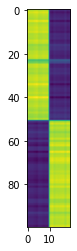

In [74]:
mat = np.array(mat.tolist())
plt.imshow(mat)

In [75]:
pd.DataFrame(mat)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.321453,1.303162,1.302132,1.343669,1.379681,1.280755,1.299450,1.340823,1.325605,1.347671,-1.285174,-1.358600,-1.260030,-1.308204,-1.296902,-1.321815,-1.333500,-1.246608,-1.364810,-1.302282
1,1.521371,1.499429,1.501538,1.552157,1.588358,1.475301,1.507096,1.553302,1.528627,1.554188,-1.482045,-1.561249,-1.450134,-1.511409,-1.491372,-1.521348,-1.540403,-1.439656,-1.575118,-1.503449
2,1.402079,1.382507,1.382028,1.426621,1.463850,1.359044,1.380794,1.424425,1.406945,1.430387,-1.364041,-1.440954,-1.336811,-1.389007,-1.375707,-1.402381,-1.415823,-1.323498,-1.448795,-1.382511
3,1.357065,1.338692,1.336101,1.377456,1.416885,1.314905,1.329325,1.372477,1.360177,1.382765,-1.318672,-1.396557,-1.294228,-1.340997,-1.332658,-1.357641,-1.367034,-1.278132,-1.399809,-1.335447
4,1.296311,1.277749,1.279048,1.321756,1.353396,1.256938,1.282477,1.322064,1.302120,1.323876,-1.262434,-1.330727,-1.235692,-1.287023,-1.271013,-1.296359,-1.311748,-1.226012,-1.341529,-1.280414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-1.410556,-1.391983,-1.387339,-1.428668,-1.472764,-1.366269,-1.375180,-1.420876,-1.412326,-1.435711,1.369205,1.453315,1.345551,1.390723,1.386213,1.411416,1.417863,1.325878,1.452719,1.385630
96,-1.362813,-1.343084,-1.345250,-1.390830,-1.422815,-1.321612,-1.350957,-1.392228,-1.369521,-1.392432,1.327791,1.398292,1.298957,1.354335,1.335795,1.362756,1.380297,1.289989,1.411281,1.347109
97,-1.383734,-1.365338,-1.361438,-1.402537,-1.444750,-1.340446,-1.351227,-1.395771,-1.385962,-1.408934,1.343655,1.425107,1.319862,1.365330,1.359510,1.384490,1.391927,1.301550,1.425856,1.360106
98,-1.352965,-1.334996,-1.331116,-1.371244,-1.412625,-1.310623,-1.320957,-1.364540,-1.355093,-1.377551,1.313727,1.393476,1.290524,1.334863,1.329315,1.353713,1.360872,1.272519,1.394073,1.329779


In [53]:
lrnr.weight

<bound method EmbeddingDotBias.weight of EmbeddingDotBias(
  (u_weight): Embedding(101, 2)
  (i_weight): Embedding(21, 2)
  (u_bias): Embedding(101, 1)
  (i_bias): Embedding(21, 1)
)>

In [ ]:
torch.tensor([[0,1]],dtype=torch.int64).to("cuda:0")

In [ ]:
lrnr.model(torch.tensor([[20,1]],dtype=torch.int64).to("cuda:0")) #i, u 

### 영화추천 

In [ ]:
path = untar_data(URLs.ML_100k) 

In [ ]:
ratings = pd.read_csv(path/'u.data',delimiter='\t', header=None, 
                      names=['user','movie','rating','timestamp']) 
ratings.head()

In [ ]:
movies=pd.read_csv(path/'u.item',delimiter='|', encoding='latin-1',usecols=(0,1),names=('movie','title'),header=None)

In [ ]:
movies.head()

In [ ]:
ratings = ratings.merge(movies)
ratings

In [ ]:
X = ratings[['user','movie']].values

In [ ]:
X

In [ ]:
Y = ratings[["rating"]].values

In [ ]:
Y

In [ ]:
max_user, max_item = X.max(0)

In [ ]:
max_user, max_item

In [ ]:
user_emb=nn.Embedding(944,20,0)

In [ ]:
item_emb=nn.Embedding(1682,20,0)

In [ ]:
X[0]

In [ ]:
user_emb(X[0])

In [ ]:
nn.Embedding(944,20,0) * nn.Embedding(1682,20,0)

In [ ]:
dls=CollabDataLoaders.from_df(ratings,item_name='title',bs=64)

In [ ]:
dls.show_batch()

`-` 편향이 필요한 이유: 어떤영화는 그냥 재미없을수도.. 어떤사람은 그냥 점수를 높게 줄수도 있어.. 

In [ ]:
lrnr = collab_learner(dls,n_factors=50,y_range=(0.5,5))

In [ ]:
lrnr.fit_one_cycle(5)

In [ ]:
lrnr.model.i_bias.weight.squeeze()

In [ ]:
lrnr.model.i_bias.weight.squeeze().argsort()[:5]

In [ ]:
dls.classes['title'][295]

In [ ]:
dls.classes['title'][855]

In [ ]:
dls.classes['title'][357]

In [ ]:
dls.classes['title'][62]

In [ ]:
dls.classes['title'][850]

In [ ]:
lrnr.model.i_bias.weight.squeeze().argsort(descending=True)[:5]

In [ ]:
dls.classes['title'][1501]

In [ ]:
dls.classes['title'][830]

In [ ]:
dls.classes['title'][319]

In [ ]:
dls.classes['title'][93]

In [ ]:
dls.classes['title'][1318]